In [ ]:
# Operate from the parent directory
# This allows us to import modules from the parent directory
import os
os.chdir("..")

import torch
from torch.utils.data import DataLoader
from experimental_pose_encoder_model_extension.pose_encoder import PoseEncoder
from experimental_pose_encoder_model_extension.pose_encoder_training_loop import train
import utils.utils as utils
from dataset.dataset import *

device = utils.get_device()

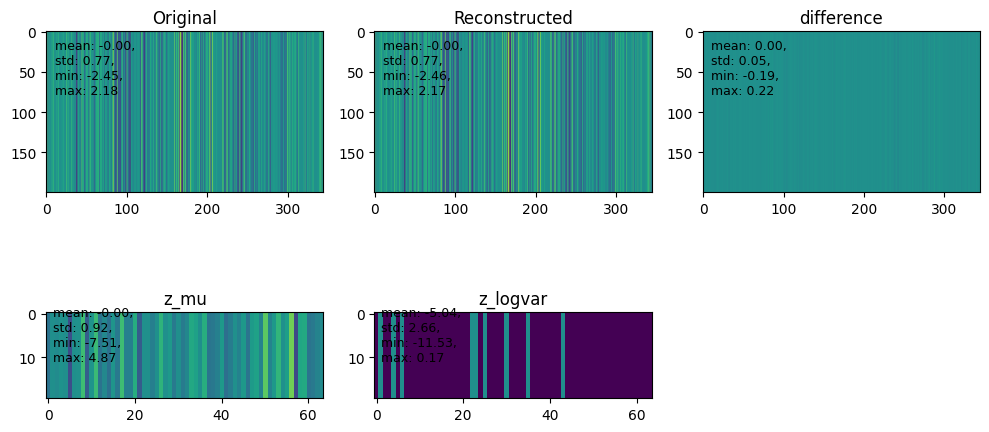

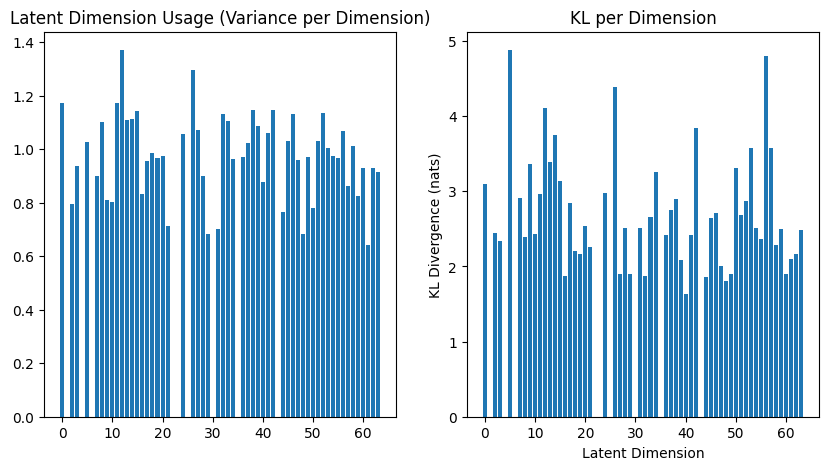

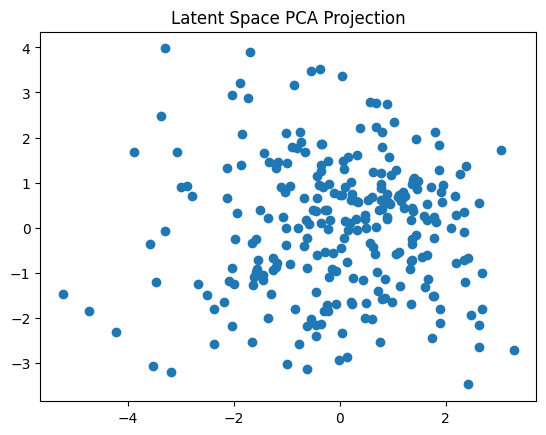

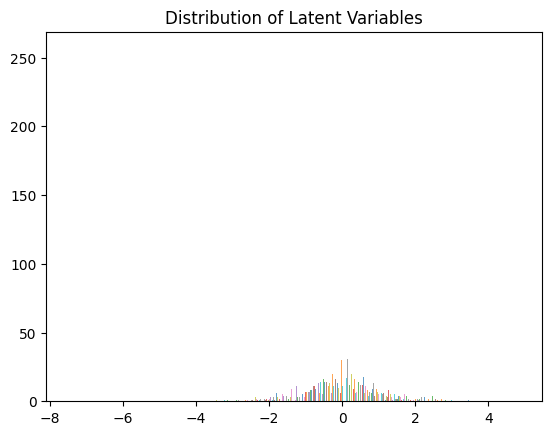

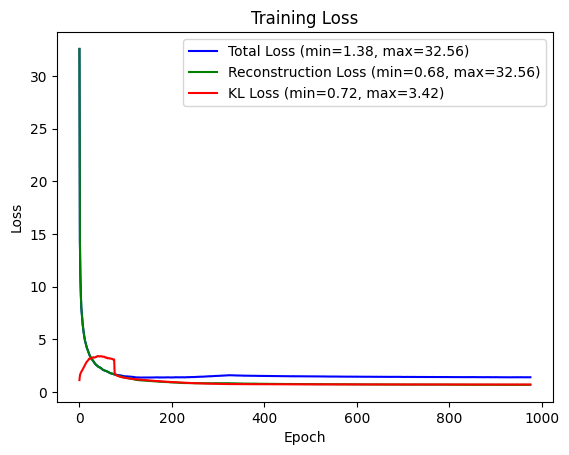

Epoch 1000/1000: 100%|██████████| 1024/1024 [00:03<00:00, 311.39it/s, Train=1.3683, Recon=0.6529, KL=159.0, Weighted: 0.715365829, weight: 0.004500000, (anneal: 1.000000000), Ratio=0.9, Active dims=55/64]


In [3]:
train(
    name="pose_encoder_test_64",
    model = PoseEncoder(z_dim=64),
    pose_training_loader = DataLoader(
        GPUDataset(
            consolidated_file = "dataset/genea2023_dataset/trn/main-agent/consolidated.npz",
            seq_length = 1, # 1 because we are extracting poses, i.e. single frames
            batch_size = 256,
            epoch_length = 1024,
            device = device
        ),
        batch_size = 1,
        num_workers = 0,
        pin_memory = False
    ),
    num_epochs = 1000,
    warm_up_kl_anneal_steps = 75,
    kl_anneal_steps = 250,
    kl_beta = 0.0045,
    category_weighting = {
        'fingers': 0.5,
        'arms': 2.0,
        'legs': 1.5,
        'spine': 1.5,
        'head': 2.0,
        'root': 3.0
    },
    visualize_steps = 25,
    device = device
)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

def mahalanobis_distance(z: torch.Tensor):
    # z: [N, D]
    mu = z.mean(dim=0)
    centered = z - mu
    cov = torch.cov(centered.T) + 1e-5 * torch.eye(z.size(1))
    inv_cov = torch.linalg.inv(cov)
    dists = torch.sum(centered @ inv_cov * centered, dim=1)
    return dists

# Load the dataset
dataset = GPUDataset(
    consolidated_file= "dataset/genea2023_dataset/toy/main-agent/consolidated.npz",
    seq_length=1,
    seed_length=0,
    batch_size=1,
    epoch_length=4096
)

model = PoseEncoder(
    z_dim = 48,
    pose_dim = 345,
    device = device,
    checkpoint_path = "pose_encoder_test_48.pth"
)

data_loader = DataLoader(dataset, batch_size=10000, shuffle=True)

all_latent_samples = []

# Example of generating latent samples
with torch.no_grad():  # No need to compute gradients for latent sampling
    for batch_idx, batch_data in enumerate(data_loader):

        x, _, _, _ = [
            item.squeeze(1).squeeze(1).float().to(device) for item in batch_data
        ]

        print(f"x shape: {x.shape}")
        
        x = x.to(device)  # Move data to device (GPU or CPU)
        mu, logvar = model.encode(x, return_logvar=True)  # Get mean and log-variance from the encoder
        latent_sample = model.reparameterize(mu, logvar)  # Generate latent sample
        all_latent_samples.append(latent_sample.cpu())  # Store latent samples (move to CPU if needed)

# Combine all latent samples into a single tensor
latent_samples = torch.cat(all_latent_samples, dim=0)  # Shape: [num_samples, z_dim]

print(f"Latent samples shape: {latent_samples.shape}")

# Example:
z = latent_samples.cpu().numpy()  # shape [N, D]
dists = mahalanobis_distance(latent_samples)

# Compare with chi-squared distribution
df = z.shape[1]
plt.hist(dists.numpy(), bins=50, density=True, alpha=0.6, label='Empirical')
x = np.linspace(0, np.max(dists.cpu().numpy()), 200)
plt.plot(x, chi2.pdf(x, df), label=f'Chi²(df={df})')
plt.title("Mahalanobis Distance vs Chi² Distribution")
plt.legend()
plt.show()

import scipy.stats as stats

def qq_plot(z: torch.Tensor):
    D = z.shape[1]
    fig, axs = plt.subplots(nrows=(D + 3) // 4, ncols=4, figsize=(16, 3 * ((D + 3) // 4)))
    axs = axs.flatten()
    for i in range(D):
        stats.probplot(z[:, i], dist="norm", plot=axs[i])
        axs[i].set_title(f'Dim {i}')
    plt.tight_layout()
    plt.show()

# Usage
qq_plot(z)

Initializing GPU-resident dataset on cuda
Loading data from dataset/genea2023_dataset/toy/main-agent/consolidated.npz directly to GPU...
Data loaded to GPU. Gesture shape: torch.Size([49628, 345]), Audio shape: torch.Size([49628, 37])
Found 49628 valid starting points for windows
Dataset initialization complete!


RuntimeError: Error(s) in loading state_dict for PoseEncoder:
	Missing key(s) in state_dict: "encoder.0.weight", "encoder.0.bias", "encoder.1.weight", "encoder.1.bias", "encoder.3.weight", "encoder.3.bias", "encoder.4.weight", "encoder.4.bias", "encoder.6.weight", "encoder.6.bias", "encoder.7.weight", "encoder.7.bias", "fc_mu.weight", "fc_mu.bias", "fc_logvar.weight", "fc_logvar.bias", "decoder.0.weight", "decoder.0.bias", "decoder.1.weight", "decoder.1.bias", "decoder.3.weight", "decoder.3.bias", "decoder.4.weight", "decoder.4.bias", "decoder.6.weight", "decoder.6.bias", "decoder.7.weight", "decoder.7.bias", "decoder.9.weight", "decoder.9.bias". 
	Unexpected key(s) in state_dict: "fc1.weight", "fc1.bias", "fc2_mu.weight", "fc2_mu.bias", "fc2_logvar.weight", "fc2_logvar.bias", "fc3.weight", "fc3.bias", "fc4.weight", "fc4.bias". 